In [1]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator
from scipy.constants import c, h, N_A
from scipy.special import gammainc, gamma

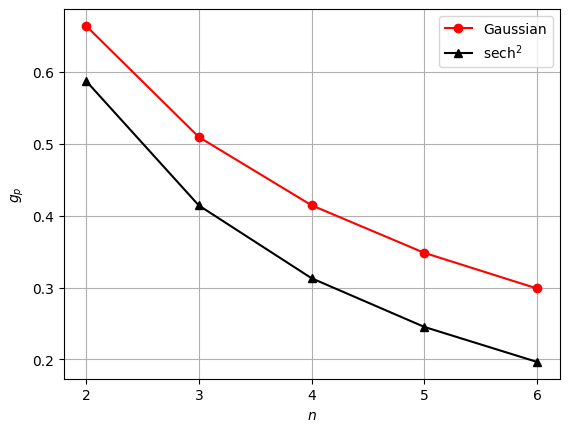

In [20]:
n = np.arange(2, 7)

def g_p_gauss(n):
    return np.sqrt((4*np.log(2)/np.pi)**(n-1)/n)

def g_p_sech2(n):
    return np.sqrt(np.pi)*(np.log(1+np.sqrt(2)))**(n-1) * gamma(n) / (gamma(n+1/2)) /2

plt.plot(n, g_p_gauss(n), marker='o', c='r', label='Gaussian')
plt.plot(n, g_p_sech2(n), marker='^', c='k', label=r'sech$^2$')
plt.xticks(n)
plt.xlabel(r'$n$')
plt.ylabel(r'$g_p$')
plt.grid()
plt.legend()
plt.show()

### overlap integral to calculate ROI-beam-overlap $\xi$
For a Gaussian:
$$\xi(\alpha,\,\beta) \equiv \frac{2}{\pi}\left(\theta_R - e^{4\alpha^2} \int_0^{\theta_R} d\theta\exp\left[-4\left(\alpha^2+\beta^2\right)\cos^2\theta\right]\right)$$
and for super-Gaussian ($m>1$)
$$\xi_m(\alpha,\,\beta) \equiv \frac{2}{\pi}\int_{0}^{\theta_R}d\theta\gamma\left(1/m,\,4\left[(\alpha^2+\beta^2)\cos^2\theta-\alpha^2\right]^m\right)$$


In [ ]:
# ---- Define the integrand ----
def integrand(theta, alpha, beta, m):
    return gammainc(1/m, 4*( (alpha**2+beta**2) * np.cos(theta)**2 - alpha**2)**m)

# ---- Full expression ----
def theta_R(alpha, beta):
    return np.arctan(beta / alpha)

def xi(alpha, beta, m):
    if alpha == 0:
        return 0.0  # avoid division issues / trivial case

    theta_r = theta_R(alpha, beta)

    if m == np.inf:
        d = (alpha**2 - beta**2)/2
        if beta < 1:
            return 2*(-1*d*theta_r + alpha*beta/2)/np.pi
        else:
            return 2*(-1*d*theta_r + alpha*beta/2 + (1+d)*np.arctan(np.sqrt((beta**2-1)/(alpha**2+1)))-np.sqrt((alpha**2+1)*(beta**2-1))/2)/np.pi

    else:

        integral, _ = quad(
            integrand,
            0.0,
            theta_r,
            args=(alpha, beta, m),
            limit=2000
        )

        return 2/np.pi*integral

In [ ]:
# ---- Plot ----
def plot_xi(A, B, xis, alpha_constants=1, R_constants=5, m=1, beta_half=True, wl=930, n=1.36):
    if type(alpha_constants) != list:
        alpha_constants = [alpha_constants]

    if type(R_constants) != list:
        alpha_constants = [alpha_constants]

    if m == np.inf:
        function_title = r'$\xi_{m\rightarrow\infty}$'
    else:
        function_title = fr'$\xi_{{{m}}}$'

    fig, axs = plt.subplots(1, 3, figsize=(21, 6))
    plt.suptitle(fr'Numerical evaluation of {function_title}$(\alpha,\,\beta)$')
    im = axs[0].contourf(A, B, xis, levels=np.linspace(0, 1, 51))
    axs[0].set_xlabel(r'$\alpha$')
    axs[0].set_ylabel(r'$\beta$')
    
    divider = make_axes_locatable(axs[0])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax)

    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    
    if beta_half:
        beta_halves = B[np.argmin(np.abs(xis-1/2), axis=0)]
        axs[0].plot(A[0,:], beta_halves, c='k')

    axs[1].set_ylabel(fr'{function_title}$(\alpha,\,\beta)$')
    axs[1].set_xlabel(r'$\beta$')
    axs[1].set_ylim(0, 1)
    axs[1].set_xlim(np.min(B), np.max(B))
    axs[1].grid(True)

    axs[2].sharey(axs[1])
    axs[2].set_xlabel(r'$\alpha$')
    axs[2].set_xlim(np.min(A), np.max(A))
    axs[2].grid(True)

    for alpha_constant in alpha_constants:
        i1 = np.argmin(np.abs(A[0,:]-alpha_constant))
        xis_alpha_constant = xis[:,i1]
        axs[0].vlines(alpha_constant, np.min(A), np.max(A), linestyle='--', color='r')
        axs[1].semilogx(B[:,0], xis_alpha_constant, linestyle='--', color='r')

    for R_constant in R_constants:

        beta_R_constant = np.pi*n*R_constant / (A[0,:]*wl) *1e3
        mask = (
            (beta_R_constant >= B.min()) &
            (beta_R_constant <= B.max())
        )

        alpha_R_constant = A[0,:][mask]
        beta_R_constant = beta_R_constant[mask]
        interpolate = RegularGridInterpolator((A[0,:], B[:,0]), xis)
        xis_R_constant = interpolate(np.column_stack((beta_R_constant, alpha_R_constant)))

        axs[0].plot(alpha_R_constant, beta_R_constant, linestyle=':', c='r')
        axs[2].semilogx(alpha_R_constant, xis_R_constant, linestyle=':', color='r')

    plt.show()

In [ ]:
# ---- Parameter grid ----
alphas = np.geomspace(0.01, 1e3, 500)
betas  = np.geomspace(0.01, 1e3, 500)
ms = [1, 2, 5, 30, np.inf]

A, B = np.meshgrid(alphas, betas)

xis = np.zeros_like(A)

xis_m = np.array([])


for l, m in enumerate(ms):
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            xis[i, j] = xi(A[i, j], B[i, j], m)
    
    plot_xi(A, B, xis, alpha_constants=[1, 5], R_constants=[5, 10], m=m)
    xis_m = np.append(xis_m, xis)

xis_m = xis_m.reshape((len(ms), A.shape[0], A.shape[1]))


### Beam efficiency for super-Gaussian

$$\chi(m)=\frac{m}{\Gamma(1/m)}$$

In [ ]:
def chi(m):
    return m/gamma(1/m)

ms = np.geomspace(1, 1000, 1000)
chis = chi(ms)

plt.semilogx(ms, chis, color='k')
plt.xlabel(r'$m$')
plt.ylabel(r'$\chi(m)$')
plt.grid()
plt.show()

In [ ]:
alphas = np.geomspace(0.01, 1e3, 100)
betas  = np.geomspace(0.01, 1e3, 100)

A, B = np.meshgrid(alphas, betas)

xis = np.zeros_like(A)

m = np.inf

for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        xis[i, j] = xi(A[i, j], B[i, j], m)
plot_xi(A, B, xis, alpha_constant=.1, m=m)

In [ ]:
ms = np.geomspace(1, 1000, 100)
xis = np.zeros_like(ms)


for i, m in enumerate(ms):
    xis[i] = xi(1, 1, m)

    
plt.semilogx(ms, xis)


plt.hlines(1/np.pi, np.min(ms), np.max(ms))
plt.vlines(ms[39], np.min(xis), np.max(xis))
plt.grid()
plt.show()
plt.plot(ms[1:], np.diff(xis))
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.show()
plt.semilogx(ms, xis/xi(1, 1, np.inf))
plt.show()

### photon count estimate

$$N_{det}^{spot}(t) = \frac{\pi n \lambda g_p\Phi \sigma \chi \xi \eta^2\eta_{\mathrm{NA}}}{2h^2 c^2 f_p \tau_p N_{ROI}^2}P^2 C(t)$$

In [ ]:
def EFF(Phi = 0.7,
               eta = 0.6,
               eta_NA = 0.4,
               chi = 1,
               xi = 1):
    return Phi*xi*chi*eta**2*eta_NA

EFF()

In [ ]:
def kappa_B(Ca, B_tot, K_d):
    return K_d * Ca * B_tot / (K_d + Ca)**2

def c(Ca, B_tot, kappa_B, kappa_S):
    kappa_B = kappa_B(Ca, B_tot, K_d)
    return kappa_B * Ca / (1 + kappa_B + kappa_S)

def Ca(t, Ca_rest, Ca_in, gamma=1):
    return (Ca_rest + Ca_in) / (1 + kappa_B + kappa_S)

In [ ]:
from scipy.optimize import brentq


def equilibrium_criterion(Ca, Ca_0, B_0s, Ks):
    return Ca*(1 + np.sum( B_0s/(Ks + Ca) )) - Ca_0


def calcium_equilibrium(Ca_0,
                        B_0s,
                        Ks):

    B_0s = np.asarray(B_0s, dtype=float)
    Ks = np.asarray(Ks, dtype=float)

    Ca = brentq(equilibrium_criterion, 0.0, Ca_0, args=(Ca_0, B_0s, Ks))

    return Ca


def CaB_equilibrium(Ca_eq, B_0, K):
    return Ca_eq * B_0 / (K + Ca_eq)


Ks = [1, 100, 200, 1000]
B_0s = [10, 100, 200, 2000]
Ca_0s = np.linspace(0, 3000, 100)

CaB_matrix = np.zeros( (len(B_0s), len(Ca_0s)) )
Ca_eqs = np.zeros_like(Ca_0s)

for j, Ca_0 in enumerate(Ca_0s):
    Ca_eqs[j] = calcium_equilibrium(Ca_0, B_0s, Ks)
    for i, (B_0, K) in enumerate(zip(B_0s, Ks)):
        CaB_matrix[i, j] = CaB_equilibrium(Ca_eqs[j], B_0, K)

for i, row in enumerate(CaB_matrix):
    plt.plot(Ca_0s, row, label=fr'[CaB$_{{{i+1}}}$]')
    plt.plot(Ca_0s, B_0s[i]-row, label=fr'[B$_{{{i+1}}}$]')

plt.plot(Ca_0s, Ca_eqs, label=r'[Ca$^{2+}$]')
plt.legend()
plt.grid()
#plt.xscale('log')
plt.show()

In [ ]:
B_0 = 10 #uM
Ca_rest = 50 #nM 
dCa = 150 #nM
K_I = 108 #nM

def CaB(Ca, K_I, B_0):
    return B_0*Ca/(K_I+Ca)

def dCaB(Ca_rest, dCa, K_I, B_0):
    return CaB(Ca_rest+dCa, K_I, B_0) - CaB(Ca_rest, K_I, B_0)

dcab = dCaB(Ca_rest, dCa, K_I, B_0) #uM
print(dcab)

In [ ]:
def N_det_spot(P = 2,
               C = 2e-6*N_A,  
               wl = 930e-9,
               g_p = 0.588,
               Phi = 0.7,
               eta = 0.6,
               eta_NA = 0.4,
               sigma = 50e-58,
               f_p = 80e6,
               tau_p = 140e-15,
               chi = 1,
               xi = 1,
               n = 1.36,
               N_ROI = 50):
    return (np.pi*n*wl*g_p*Phi*sigma*xi*chi*eta**2*eta_NA*P**2*C) / (2*h**2*c**2*f_p*tau_p*N_ROI**2)

def N_ROI(dz, rho, A, M):
    return int(rho*dz*A/M**2)


def pixelspread(wl, DMD_pitch, M, camera_pitch):
    return max([np.pi * (max([0.61*wl, DMD_pitch/M])*M / camera_pitch)**2/4, 1])


def SNR(N_AP,
        N_0,
        dt,
        QE = 0.74,
        I_dark = 1.54,
        sigma_read = 2.6,
        sigma_DS = 0,
        k_PR = 0.00):
    return QE*dt*(N_AP-N_0) / np.sqrt(QE*N_AP*dt+I_dark*dt + sigma_read**2 + sigma_DS**2 + (k_PR*QE*N_AP*dt)**2)


SNR(20, 10, 1, 2)

In [ ]:
N = 16

N_rest = N_det_spot(C=CaB(Ca_rest, K_I, B_0)*1e-6*N_A, N_ROI=N)
N_AP = N_det_spot(C=CaB(Ca_rest+dCa, K_I, B_0)*1e-6*N_A, N_ROI=N)

print(N_rest, N_AP)

M = 40
DMD_pitch = 7.6e-6
wl = 930e-9
camera_pitch = 10e-6

print(pixelspread(wl, DMD_pitch, M, camera_pitch))

dt=1/1594

SNR(N_AP/pixelspread(wl, DMD_pitch, M, 10e-6), N_rest/pixelspread(wl, DMD_pitch, M, 10e-6), dt=dt)

In [ ]:
M = 40
DMD_pitch = 7.6e-6
wl = 930e-9
camera_pitch = 24e-6

def SNR(N_AP,
        N_0,
        dt,
        QE = 0.75,
        I_dark = .003,
        sigma_read = 0.2,
        sigma_DS = 0,
        k_PR = 0):
    return QE*dt*(N_AP-N_0) / np.sqrt(QE*N_AP*dt+I_dark*dt + sigma_read**2 + sigma_DS**2 + (k_PR*QE*N_AP*dt)**2)


Ms = [16, 25, 40]

for N, M in zip([194, 79, 31], Ms):
    for f in [1250, 2500]:
        N_rest = N_det_spot(C=CaB(Ca_rest, K_I, B_0)*1e-6*N_A, N_ROI=N)
        N_AP = N_det_spot(C=CaB(Ca_rest+dCa, K_I, B_0)*1e-6*N_A, N_ROI=N)
        pixel_spread = pixelspread(wl, DMD_pitch, M, camera_pitch)
        snr = SNR(N_AP/pixel_spread, N_rest/pixel_spread, dt=1/f)#, QE=qe)#, I_dark=I_dark, sigma_read=sigma_read, sigma_DS=sigma_DS, k_PR=k_PR)
        print(f'N: {N}')
        print(f'M: {M}')
        print(f'N_rest: {N_rest}')
        print(f'N_AP: {N_AP}')
        print(f'pixel spread: {pixel_spread}')
        print(f'dt: 1/{f} = {1/f*1000}')
        print(f'SNR: {snr}')
        print('____________________________________________')
    print('____________________________________________')

### Group Delay Dispersion of a Sech^2 pulse

In [ ]:
tau = 140e-15 #fs
time = np.linspace(-10*tau, 10*tau, 1000)
pulse_in = 1/np.cosh(time/tau*2*np.log(1+np.sqrt(2)))
GDD = 100e-30

plt.plot(time, pulse_in, label='pulse_in')

def broaden_pulse(time, pulse, GDD):
    pulse_fft = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(np.sqrt(pulse))))
    freqs = np.fft.fftshift(np.fft.fftfreq(time.shape[-1], d=(time[1]-time[0])))

    pulse_fft *= np.exp(1j * 0.5 * GDD * (2 * np.pi * freqs)**2)

    return np.abs(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(pulse_fft))))**2


def fwhm(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    # Normalize (important if baseline not zero)
    y = y - np.min(y)
    ymax = np.max(y)

    if ymax == 0:
        raise ValueError("Signal has zero amplitude.")

    half_max = ymax / 2.0

    # Find indices where signal crosses half max
    indices = np.where(y >= half_max)[0]

    if len(indices) < 2:
        raise ValueError("Signal does not cross half maximum twice.")

    i_left = indices[0]
    i_right = indices[-1]

    # --- Linear interpolation for better accuracy ---

    def interp_cross(i1, i2):
        x1, x2 = x[i1], x[i2]
        y1, y2 = y[i1], y[i2]
        return x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)

    # Left crossing
    if i_left == 0:
        x_left = x[0]
    else:
        x_left = interp_cross(i_left - 1, i_left)

    # Right crossing
    if i_right == len(y) - 1:
        x_right = x[-1]
    else:
        x_right = interp_cross(i_right, i_right + 1)

    width = x_right - x_left

    return width

from scipy.integrate import trapezoid

def g_p(time, pulse, tau):
    num = trapezoid(pulse**2, x=time)
    den = trapezoid(pulse, x=time)**2
    return num / den * tau




pulse_out = broaden_pulse(time, pulse_in, GDD)
plt.plot(time, pulse_out, label='pulse_out')
plt.legend()
print(fwhm(time, pulse_in))

In [ ]:
tau = 140e-15 #fs
time = np.linspace(-100*tau, 100*tau, 10000)
GDDs = np.linspace(0, 3*tau**2, 1000)
taus = []
g_ps = []
pulse_in = np.exp(-time**2/tau**2*4*np.log(2))
pulse_in = 1/np.cosh(time/tau*2*np.log(1+np.sqrt(2)))**2

for GDD in GDDs:
    pulse_out = broaden_pulse(time, pulse_in, GDD)
    plt.plot(time, pulse_out)
    taus.append(fwhm(time, pulse_out))
    g_ps.append(g_p(time, pulse_out, tau))
plt.show()

fig, ax1 = plt.subplots()

plot1, = ax1.plot(GDDs/tau**2, np.array(taus)/tau, label=r"$\tau/\tau_0$", c='r')
plot2, = ax1.plot(GDDs/tau**2, np.sqrt(1+(GDDs*4*np.log(2)/tau**2)**2), label='Gaussian approximation', c='r', ls='--')
ax1.set_xlabel(r"GDD/$\tau_0^2$")
ax1.set_ylabel(r"$\tau/\tau_0$")

ax2 = ax1.twinx()
plot3, = ax2.plot(GDDs/tau**2, g_ps, label=r'$g\times\tau_0$', c='k')
#plot4, = ax1.plot(GDDs/tau**2, np.sqrt(1+(GDDs*8*np.log(2)/tau**2)**2), label='Gaussian approximation', c='r', ls='--')
ax2.set_ylabel(r"$g\times\tau_0$")

ax1.grid(True)
ax2.grid(True)
lines = [plot1, plot2, plot3]
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="best")

plt.show()

